In [5]:
%load_ext autoreload
%autoreload 2

In [1]:
from daemon_analysis_tools.file_handling import load_and_process_csv
from daemon_analysis_tools.data.utils import group_questions_by_journal
from daemon_analysis_tools.data.publisher import Publisher
from daemon_analysis_tools.file_handling import save_answers_to_yaml, load_answers_from_yaml

Load and process data:
- Group answers by publisher and journal, trying to uniform names written in slightly different ways.
- Store in a DataFrame

In [2]:
grouped_questions = load_answers_from_yaml('../../data/processed/all_answers')

MDPI/polymers/code_linting has inconsistencies: skipped


In [3]:
for publisher, journals in grouped_questions.items():
    for journal, data in journals.items():
        for question, answer in data.items():
            if answer.has_discrepancies():
                print(publisher, journal, question, answer.discrepancy_reason)

ACS journal_of_the_american_society_for_mass_spectrometry data_fair Text not found
ACS journal_of_the_american_society_for_mass_spectrometry data_citability Text not found
ACS journal_of_the_american_society_for_mass_spectrometry data_timing Language understanding
ACS journal_of_the_american_society_for_mass_spectrometry data_sharing_method Text not found
ACS journal_of_the_american_society_for_mass_spectrometry data_licenses Text not found
ACS journal_of_the_american_society_for_mass_spectrometry data_recommended Text not found
ACS journal_of_the_american_society_for_mass_spectrometry data_required Formatting
ACS acs_omega data_sharing Text not found
ACS acs_omega data_fair Text not found
ACS acs_omega data_citability Text not found
ACS acs_omega data_timing Text not found
ACS acs_omega data_sharing_method Language understanding
ACS acs_omega data_recommended Formatting
ACS acs_omega data_required Formatting
ACS jacs data_citability Text not found
ACS jacs data_timing Language underst

Get a `dict` labeled by publisher names of `dict`s labeled by journal names of `dict`s of `Question` instances. The `.answer` attribute contains the answers given by the respondents and the explanations text to motivate it.

ACS 16
AIP 14
APS 11
Bentham Science 6
Elsevier 10
Frontiers 7
IEEE 15
IOP 9
MDPI 15
Optica 9
Pleiades Publishing 9
RSC 9
Springer Nature 10
Taylor & Francis 15
Wiley 15


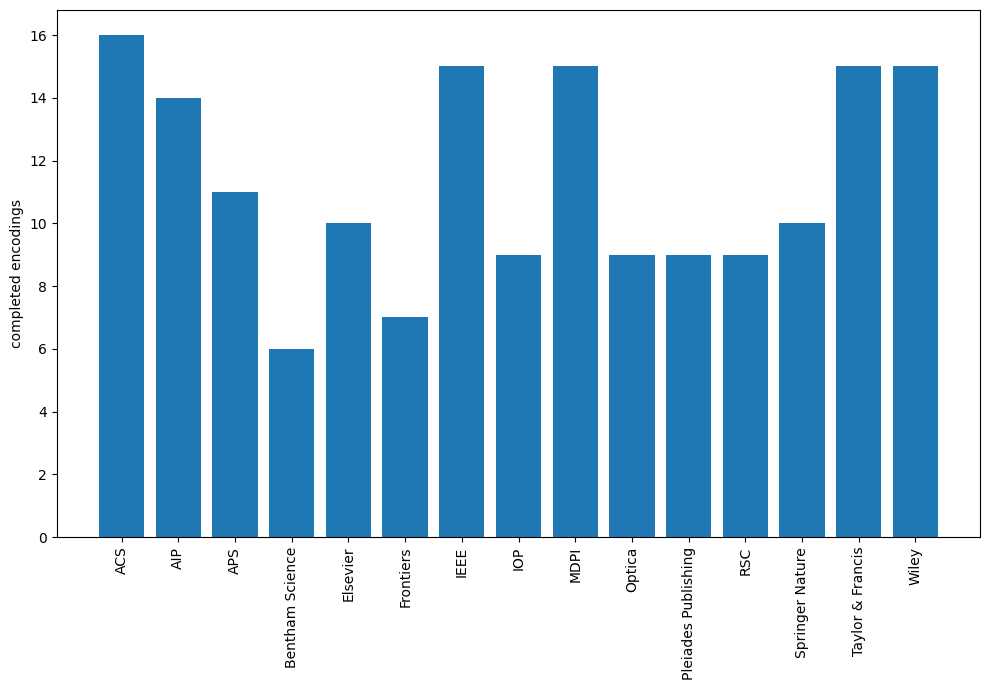

In [4]:
import matplotlib.pyplot as plt

n_journals = {}

x = []
y = []

for publisher, journals in grouped_questions.items():
    n_journals[publisher] = len(journals)

for publisher, num in n_journals.items():
    x.append(publisher)
    y.append(num)
    print(publisher, num)

x_0 = list(range(len(x)))

# Creating plot
fig = plt.figure(figsize=(10, 7))
plt.bar(x_0, y)
plt.xticks(x_0, x, rotation=90)
plt.ylabel("completed encodings")
plt.tight_layout()

fig.savefig("../../data/processed/number_of_encodings.pdf")